# HERVIOU-LABORDE Colin
# NGUYEN Minh-Quân

# TP noté -- Statistical models for decision making - partie 2

Cet devoir noté est composé de deux exercices. Il sera idéalement réalisé en binome et éventuellement seul. Les réponses seront données dans un notebook qui indiquera clairement les **noms et prénoms des élèves** l'ayant realisé.


In [1]:
# import librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import scipy.stats as stats

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import GridSearchCV, KFold


## Exercice 1

Nous souhaitons évaluer si un nouveau produit a un effet significatif sur le rendement de moteurs. Pour y répondre, ce rendement (*Efficiency*) a été mesuré sur deux types de moteurs (*Brand_1* et *Brand_2*) et en testant différents niveaux de concentration (*Concentration*) du produit. Les observations sont dans le fichier *E2_Efficiency_Obs.csv*. Plus spécifiquement, nous nous demandons :
- Le produit semble-t-il avoir un effet ?
- Cet effet est-il différent en fonction de la marque du moteur ?
- Cet effet dépend-il de la concentration du produit ?

### Question 1.1 

Ouvrez et observez les données. A leur vue, quelle vous semble être la réponse aux trois questions posées plus haut ?

In [2]:
dataframe=pd.read_csv("./E1_Efficiency_Obs.csv",sep=',')

In [3]:
dataframe.head()


,Brand,Concentration,Efficiency
0,Brand_1,3.9479,3.2224
1,Brand_1,1.7838,1.5127
2,Brand_1,7.4415,4.3736
3,Brand_1,8.5625,5.2151
4,Brand_1,9.8002,5.4256


On trace un nuage de points représentant l'efficacité du produit par rapport a sa concentration en utilisant des couleurs distinctes en fonction de lu type de moteur

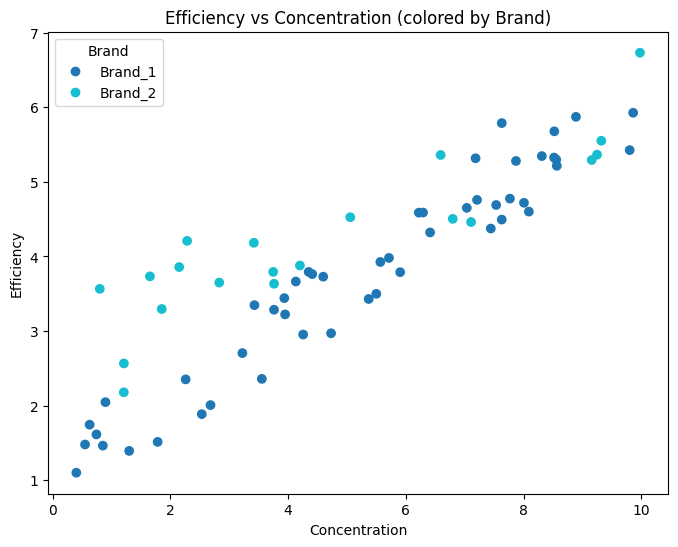

In [4]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    dataframe["Concentration"],
    dataframe["Efficiency"],
    c=pd.factorize(dataframe["Brand"])[0],  # convert brands to numbers
    cmap="tab10",                           # color palette
)

plt.xlabel("Concentration")
plt.ylabel("Efficiency")
plt.title("Efficiency vs Concentration (colored by Brand)")

# add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, dataframe["Brand"].unique(), title="Brand")

plt.show()

Comme le montre le nuage de points ci-dessus il semble y avoir une relation linéaire positive entre la concentration du produit et l'efficacité du moteur.
Au premier abord:
- Le produit semble avoir un effet positif sur l'efficacité du moteur: plus on met de produit, plus l'efficacité est améliorée.
- Cet effet serait meilleur pour le type Brand_2 que le type Brand_1, en effet, pour une même concentration, l'efficacité sur le type de moteur Brand_2 semble légèrement supérieure à celle sur le type de moteur Brand_1.
- Il y a vraisemblablement une relation linéraire positive entre la concentration du produit et l'efficacité du moteur. Cette dernière augmenterait proportionnellement avec la concentration du produit.

### Question 1.2 

Afin de répondre aux questions, deux hypothèses sont formulées :
- Pour chaque marque de moteur, la relation entre la concentration et le rendement est supposée linéaire.
- La distribution du bruit des observations est supposé suivre une loi Normale centrée.

Quelle démarche de modélisation statistique allez-vous utiliser pour répondre aux trois questions posées en introduction ? Une fois la démarche bien expliquée, testez la sur les données observées afin de conclure sur l'efficacité du produit.

On réalise une analyse de covariance (ANCOVA) afin de tester à la fois l'effet du produit et du type de moteur sur leur efficacité.

On compare un modèle linéaire complet (une régression simple par groupe). En choisissant un groupe de référence, disons le type de moteur 1. On teste ensuite les hypothèses suivantes:

- H0 : les pentes sont égales (teste la différence d'effet du produit en fonction du type de moteur)
- H0 : les intercepts sont égaux (teste l'efficacité de base des moteurs, sans produit)
- H0 : la pente du modèle du groupe de référence est nulle (teste l'effet du produit)

Pour faire cela, on compare le modèle complet aux modèles réduits correspondant à ces hypothèses. Un test de fisher teste l'égalité des variances des résidus entre le modèle complet et les différents modèles réduits.

### Modèle complet

$$
y \;=\; \beta_{0J} 1 \;+\; \beta_{1J} x \;+\;
\sum_{j=1}^{J-1} \Big( \beta'_{0j} 1_j \;+\; \beta'_{1j} x \cdot 1_j \Big)
\;+\; u
$$

Ce modèle correspond à deux régressions simples, une pour chaque groupe.


In [5]:
X = dataframe['Concentration'].values.reshape(-1, 1)
y = dataframe['Efficiency']


X1 = dataframe[dataframe['Brand'] == 'Brand_1']['Concentration'].values.reshape(-1, 1)
y1 = dataframe[dataframe['Brand'] == 'Brand_1']['Efficiency']

lr1 = LinearRegression()
lr1.fit(X1, y1)

y_pred_1 = lr1.predict(X1)


X2 = dataframe[dataframe['Brand'] == 'Brand_2']['Concentration'].values.reshape(-1, 1)
y2 = dataframe[dataframe['Brand'] == 'Brand_2']['Efficiency']

lr2 = LinearRegression()
lr2.fit(X2, y2)

y_pred_2 = lr2.predict(X2)

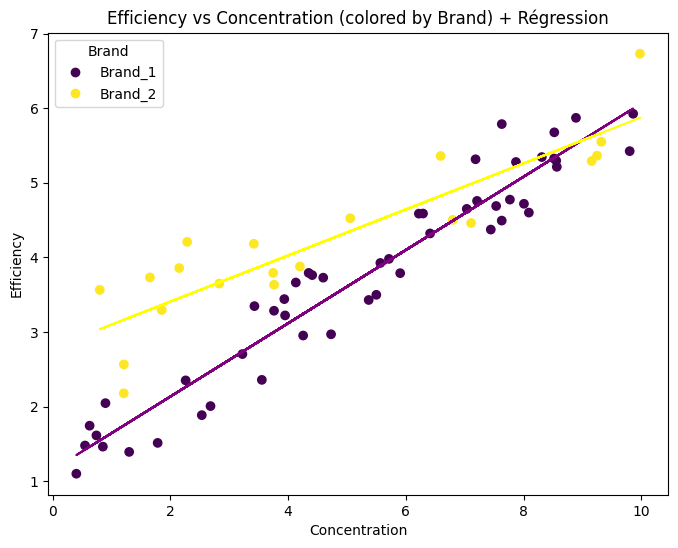

In [6]:
# Scatter plot des points
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    dataframe["Concentration"],
    dataframe["Efficiency"],
    c=pd.factorize(dataframe["Brand"])[0],  # convert brands to numbers
)

# add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, dataframe["Brand"].unique(), title="Brand")

# Ajouter la droite de régression
# plt.plot(dataframe['Concentration'], y_pred_tot, color='red', label='Régression linéaire (tous les points)')
plt.plot(X1, y_pred_1, color='purple')
plt.plot(X2, y_pred_2, color='yellow')

plt.xlabel("Concentration")
plt.ylabel("Efficiency")
plt.title("Efficiency vs Concentration (colored by Brand) + Régression")
plt.show()



In [7]:
# Calcul des résidus
res_complet = np.concatenate([y_pred_1 - y1, y_pred_2 - y2])

### (i) H0: les pentes sont égales (au modèle de référence)

$$
y \;=\; \beta_{0J} 1 \;+\; \beta_{1J} x \;+\;
\sum_{j=1}^{J-1} \Big( \beta'_{0j} 1_j \Big)
\;+\; u
$$

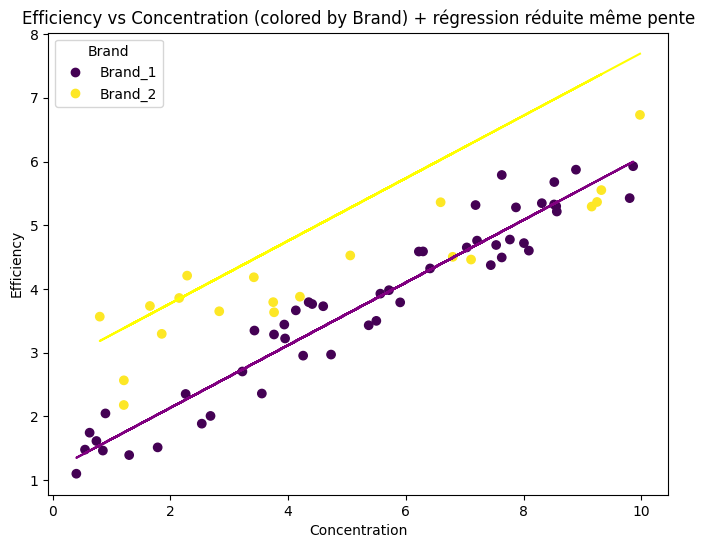

In [8]:
y_pred_2i = lr1.coef_[0] * X2 + lr2.intercept_

# Scatter plot des points
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    dataframe["Concentration"],
    dataframe["Efficiency"],
    c=pd.factorize(dataframe["Brand"])[0],  # convert brands to numbers
)

# add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, dataframe["Brand"].unique(), title="Brand")

# Ajouter la droite de régression
# plt.plot(dataframe['Concentration'], y_pred_tot, color='red', label='Régression linéaire (tous les points)')
plt.plot(X1, y_pred_1, color='purple')
plt.plot(X2, y_pred_2i, color='yellow')

plt.xlabel("Concentration")
plt.ylabel("Efficiency")
plt.title("Efficiency vs Concentration (colored by Brand) + régression réduite même pente")
plt.show()

In [9]:
# Calcul des résidus
res_réduit_i = np.concatenate([y_pred_1 - y1, y_pred_2i[:,0] - y2])

In [10]:
# F-test égalité des variances avec le modèle complet
df1 = len(X) - 1
df2 = len(X) - 1

f_value = np.var(res_réduit_i, ddof = 1) / np.var(res_complet, ddof = 1)

print('f-value = ', f_value)

p_value = 1-stats.f.cdf(f_value, df1, df2)

print('p-value = ', p_value)

f-value =  2.483184143275791
p-value =  0.00010688615686471614


La p valeur est très faible. On rejette H0 et on affirme que statistiquement, le produit a un effet et que celui-ci dépend du type de moteur.

### (ii) H0: les intercepts sont égaux

$$
y \;=\; \beta_{0J} 1 \;+\; \beta_{1J} x \;+\;
\sum_{j=1}^{J-1} \Big( \beta'_{1j} x \cdot 1_j \Big)
\;+\; u
$$

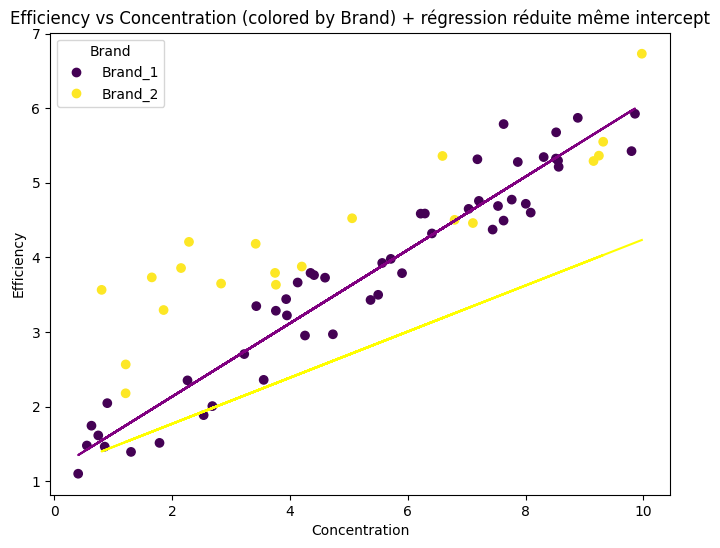

In [11]:
y_pred_2ii = lr2.coef_[0] * X2 + lr1.intercept_

# Scatter plot des points
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    dataframe["Concentration"],
    dataframe["Efficiency"],
    c=pd.factorize(dataframe["Brand"])[0],  # convert brands to numbers
)

# add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, dataframe["Brand"].unique(), title="Brand")

# Ajouter la droite de régression
# plt.plot(dataframe['Concentration'], y_pred_tot, color='red', label='Régression linéaire (tous les points)')
plt.plot(X1, y_pred_1, color='purple')
plt.plot(X2, y_pred_2ii, color='yellow')

plt.xlabel('Concentration')
plt.ylabel('Efficiency')
plt.title("Efficiency vs Concentration (colored by Brand) + régression réduite même intercept")
plt.show()

In [12]:
# Calcul des résidus
res_réduit_ii = np.concatenate([y_pred_1 - y1, y_pred_2ii[:,0] - y2])

In [13]:
# F-test égalité des variances avec le modèle complet
df1 = len(X) - 1
df2 = len(X) - 1

f_value = np.var(res_réduit_ii, ddof = 1) / np.var(res_complet, ddof = 1)

print('f-value = ', f_value)

p_value = 1-stats.f.cdf(f_value, df1, df2)

print('p-value = ', p_value)

f-value =  4.5248285295268404
p-value =  1.0862568622371782e-09


La p valeur est très faible. On rejette H0. L'efficacité de base des moteurs est différente.

### (iii) H0: la pente du modèle de référence est nulle

$$
y \;=\; \beta_{0J} 1 \;+\;
\sum_{j=1}^{J-1} \Big( \beta'_{0j} 1_j \;+\; \beta'_{1j} x \cdot 1_j \Big)
\;+\; u
$$



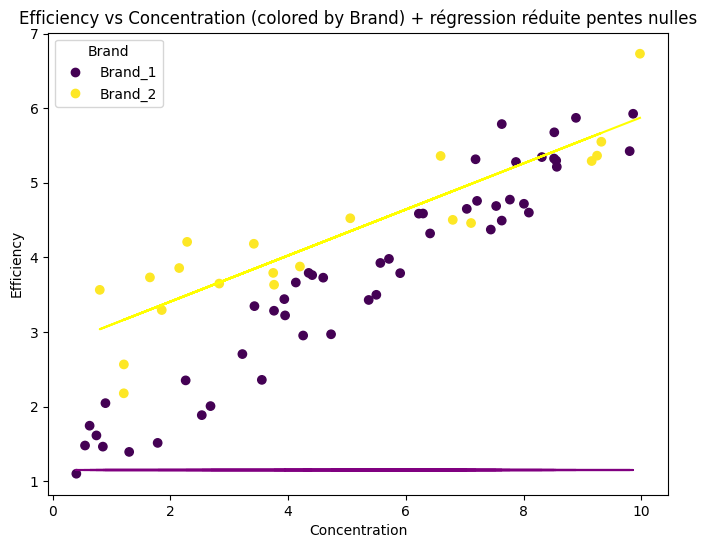

In [14]:
y_pred_1iii = 0 * X1 + lr1.intercept_

# Scatter plot des points
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    dataframe["Concentration"],
    dataframe["Efficiency"],
    c=pd.factorize(dataframe["Brand"])[0],  # convert brands to numbers
)

# add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, dataframe["Brand"].unique(), title="Brand")

# Ajouter la droite de régression
# plt.plot(dataframe['Concentration'], y_pred_tot, color='red', label='Régression linéaire (tous les points)')
plt.plot(X1, y_pred_1iii, color='purple')
plt.plot(X2, y_pred_2, color='yellow')

plt.xlabel("Concentration")
plt.ylabel("Efficiency")
plt.title("Efficiency vs Concentration (colored by Brand) + régression réduite pentes nulles")
plt.show()

In [15]:
# Calcul des résidus
res_réduit_iii = np.concatenate([y_pred_1iii[:, 0] - y1, y_pred_2 - y2])

In [16]:
# F-test égalité des variances avec le modèle complet
df1 = len(X) - 1
df2 = len(X) - 1

f_value = np.var(res_réduit_iii, ddof = 1) / np.var(res_complet, ddof = 1)

print('f-value = ', f_value)

p_value = 1-stats.f.cdf(f_value, df1, df2)

print('p-value = ', p_value)

f-value =  18.06732172780374
p-value =  1.1102230246251565e-16


La p valeur est très faible (<0.01). On rejettte l'hypothèse selon laquelle le produit n'aurait pas d'effet sur le moteur. On peut affirmer que le produit a un effet sur l'efficacité du moteur.

## Exercice 2


Afin d'estimer efficacement le niveau de fatigue des ailes d'un d'avion au cours des années, il a été proposé de lancer une étude pour évaluer s'il était possible de déduire le niveau de stress subit par les ailes de l'avion lors de phases de vols diverses avec de données capteurs acquises en routine pendant les vols. Une personne ayant une expertise mécanique sur le modèle d'avion étudié a alors quantifié le niveau de stress subi par les ailes dans différentes phases de vols et différents contextes. Nous allons mettre en lien ces niveaux de stress avec des données capteurs acquises au même moment que les annotations. Nous allons pour cela utiliser la régression linaire. 


### QUESTION 2.1

Les données d'apprentissage sont dans les fichiers *E2_sensor_vals.csv* et *E2_stress_vals.csv*. Ouvrez ces fichiers et mettez les données dans des numpy arrays ou des pandas dataframes *X* et *Y*. Représentez alors le lien entre les valeurs issues de chaque capteur et le niveau de stress dans des nuages de points 2D. Identifiez-vous des relations entre des données capteur et le niveau de stress ? Quels capteurs vous paraissent être les plus pertinents.
 

In [55]:
X = pd.read_csv('E2_sensor_vals.csv', delimiter=';')

Y = pd.read_csv('E2_stress_vals.csv')


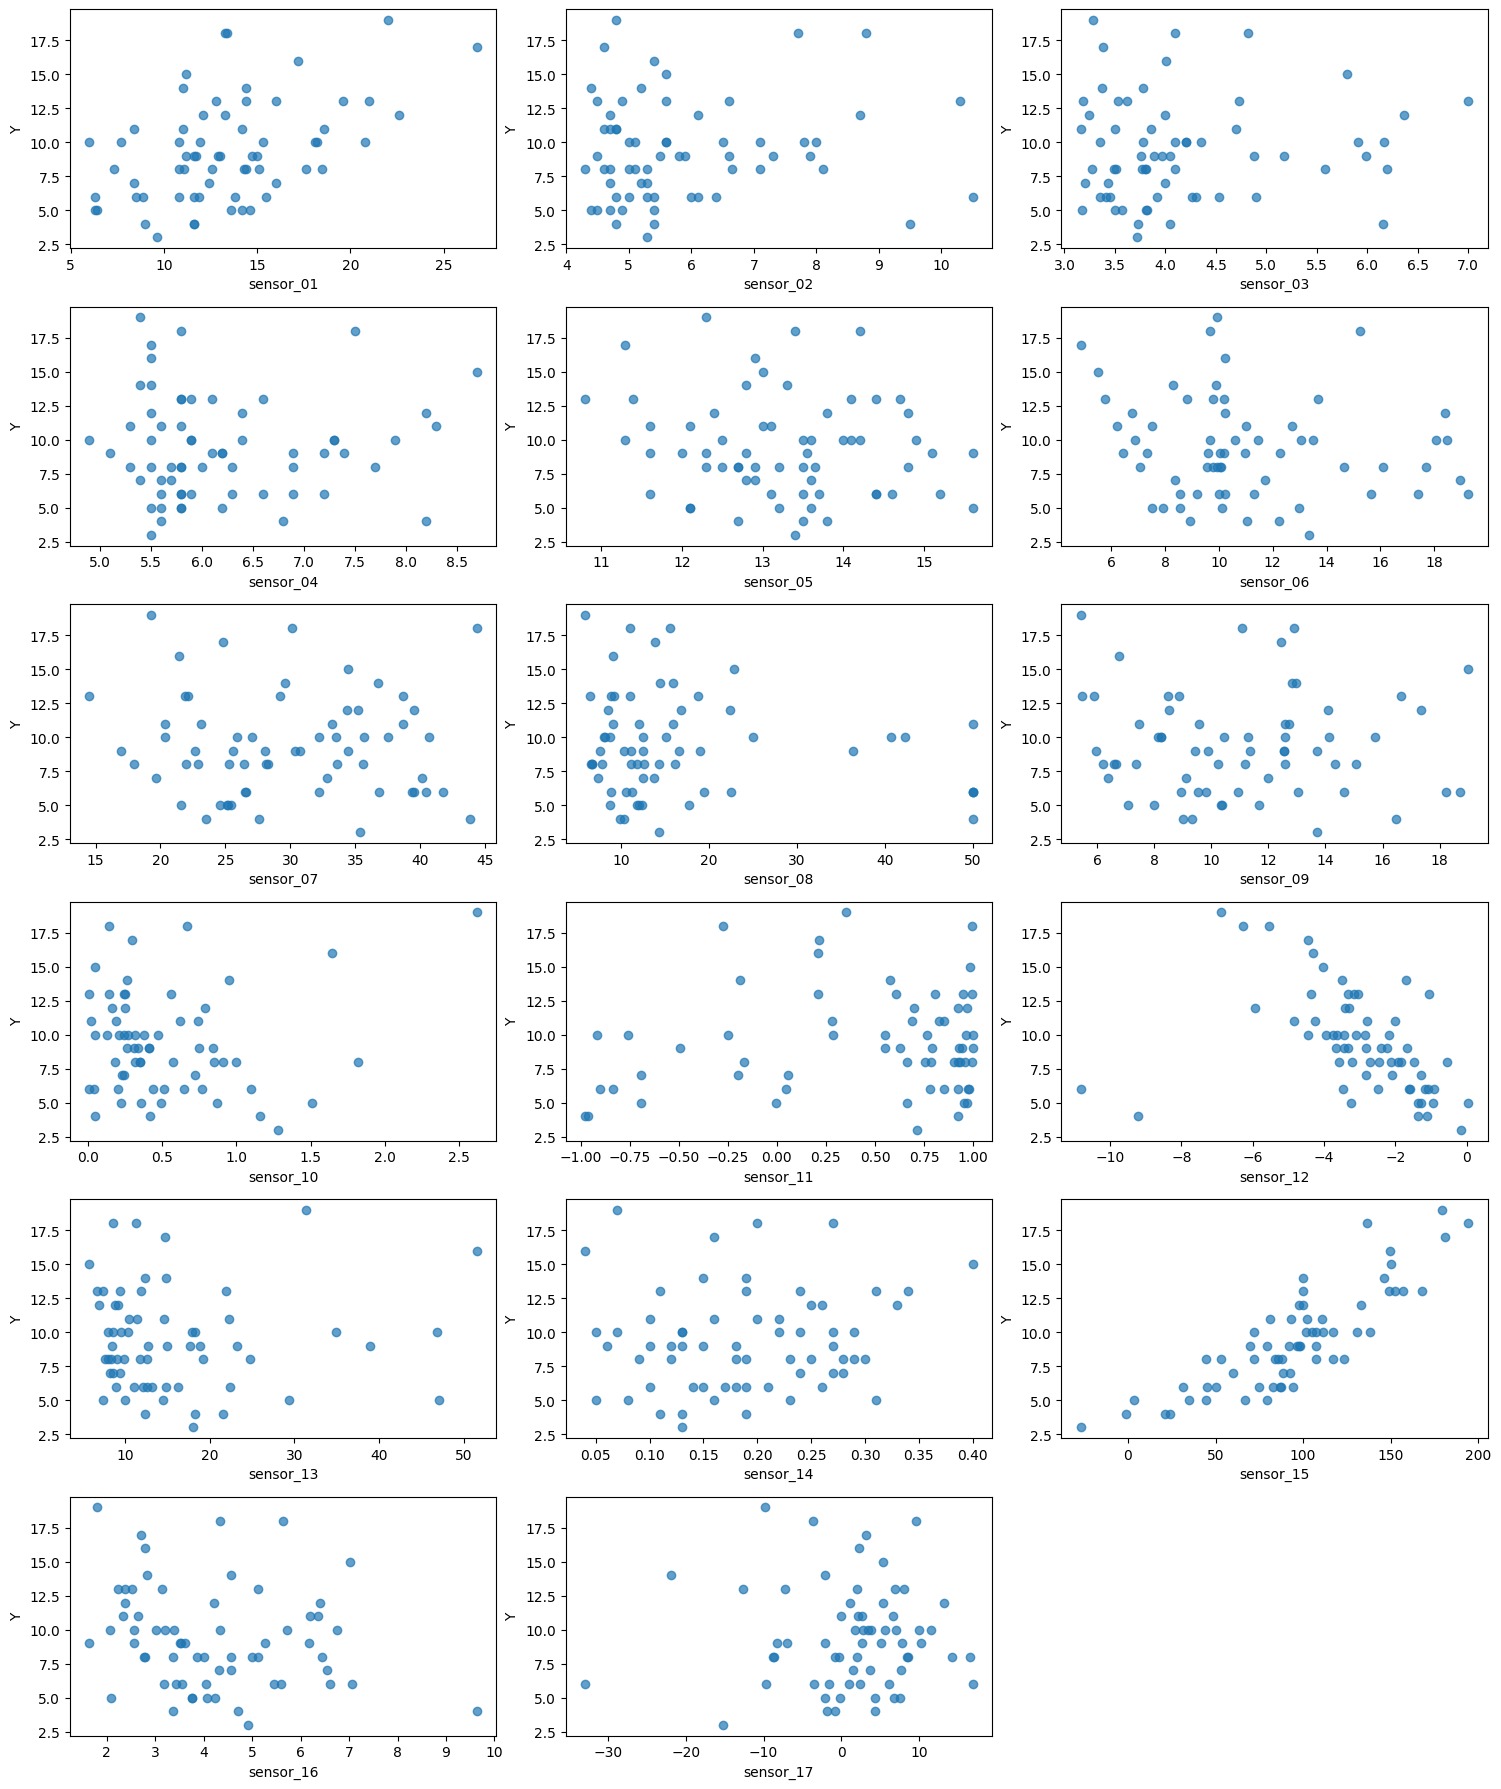

In [18]:
# S'assurer que Y est un vecteur 1D (au cas où il ait une seule colonne)
if Y.shape[1] == 1:
    y = Y.iloc[:, 0]
else:
    raise ValueError("Y contient plus d'une colonne, préciser laquelle utiliser.")

# Nombre de variables dans X
n_features = X.shape[1]

# Définir le nombre de lignes/colonnes pour les subplots
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

# Création des subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten()  # Pour indexer facilement

for i, col in enumerate(X.columns):
    axes[i].scatter(X[col], y, alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Y")

# Supprimer les axes inutilisés si le nombre de subplots est supérieur au nombre de colonnes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Il ne semble pas y avoir de corrélation / relation entre les données capteurs et le niveau de stress pour la plupart des capteurs. Cependant, les données des capteurs 12 et 15 paraissent linéairement liés au niveau de stress subit par les ailes d'avion.

### QUESTION 2.2
On se demande s'il est possible de prédire le niveau de stress à partir d'**une seule** des variables *sensor_01*, *sensor_12* ou *sensor_15*.

#### QUESTION 2.2.1

Effectuez une régression linéaire simple entre chacune de ces trois variables et le niveau de stress. Quelle stratégie de validation croisée vous semble être la plus adaptée sur ce jeu de données ?


In [19]:
print(X.shape)

(64, 17)


Le jeu de données comporte relativement peu d'observations, seulement 64. Afin d'utiliser au maximum ces données, on peut se permettre d'utiliser une stratégie de Leave One Out afin d'avoir une estimation fiable des coefficients de la régression linéaire.

sensor_01 : MSE = 11.152054867573712
sensor_12 : MSE = 13.97276798253475
sensor_15 : MSE = 4.108440427411133


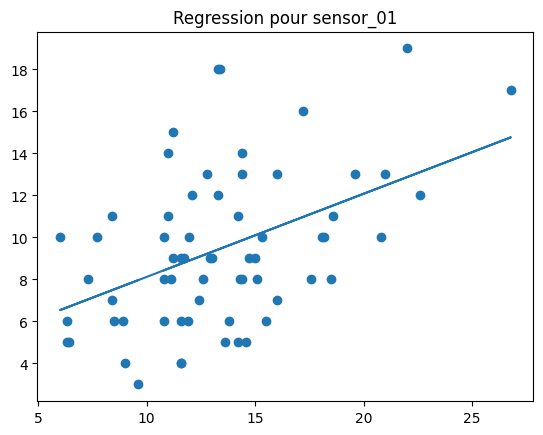

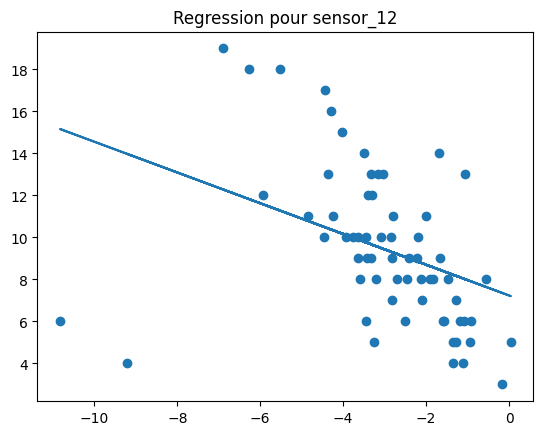

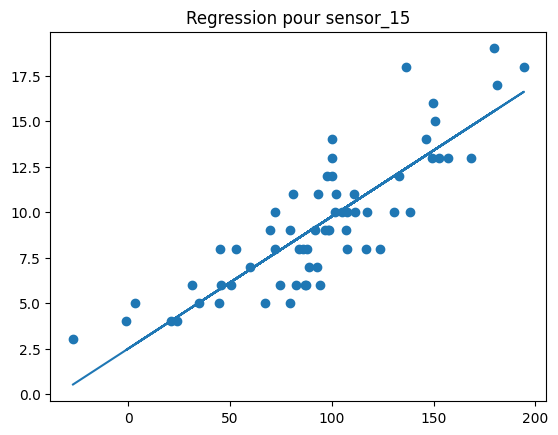

In [20]:
loo = LeaveOneOut()

sensors = ['sensor_01', 'sensor_12', 'sensor_15']

for sensor in sensors:

    x = X[sensor].values.reshape(-1, 1)

    sum_mse_scores = 0

    for train_index, test_index in loo.split(x):

        X_train, X_test = x[train_index], x[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        lr = LinearRegression()
        lr.fit(X_train, y_train)

        y_pred = lr.predict(X_test)

        mse_score_lasso = mean_squared_error(y_test, y_pred)
        sum_mse_scores+=mse_score_lasso
    
    plt.figure()
    plt.scatter(x, Y)
    plt.plot(x, lr.predict(x))
    plt.title(f'Regression pour {sensor}')

    print(f'{sensor} : MSE = {sum_mse_scores / x.shape[0]}')

#### QUESTION 2.2.2

Peut-on statistiquement affirmer qu'il existe une relation significative entre le niveau de stress et (indépendament) *sensor_01*, *sensor_12* ou bien *sensor_15* ? Si oui, décrivez votre procédure de test.

La procédure est la suivante:

- Pour chaque capteur, ajuster un modèle linéaire $ y = \beta_0 + \beta_1 * x $
- Tester l'hypothèse H0: $ \beta_1 = 0$
- On réalise un test de Student pour déterminer si la pente est significative ou non

In [22]:
# test H0 : Beta1 = 0
from scipy.stats import t

def s2(y_true, y_pred):
    n = len(y_true)
    SSE = np.sum((y_true - y_pred)**2)
    return SSE / (n-1)

def sample_T_n(b_1, beta_1, s, s_x):
    return (b_1 - beta_1)/(s/s_x)

for sensor in sensors:

    x = X[sensor].values.reshape(-1, 1)

    lr = LinearRegression()
    lr.fit(x, y)
    y_pred = lr.predict(x)
    b_0 = lr.intercept_
    b_1 = lr.coef_[0]
    s_2 = s2(y, y_pred)
    s = np.sqrt(s_2)
    s_x = np.sqrt(np.sum((x-np.mean(x))**2))

    t_ = sample_T_n(b_1, 0, s, s_x)

    alpha = 5/100
    p_fractile = 1-alpha/2
    t_fractile = t.ppf(p_fractile, df=len(y)-2)

    print(sensor)
    print('t = ', t_)
    print('P(T_n <= t_{1-alpha/2}) = ', p_fractile)
    print('t_{1-alpha/2} = ', t_fractile)
    print(f'On rejette H_0 avec un risque {alpha} si |t| >= t_{1-alpha/2}: ', abs(t_) >= t_fractile)
    print('================================')

sensor_01
t =  4.227867742483123
P(T_n <= t_{1-alpha/2}) =  0.975
t_{1-alpha/2} =  1.9989715170333786
On rejette H_0 avec un risque 0.05 si |t| >= t_0.975:  True
sensor_12
t =  -3.540241689357149
P(T_n <= t_{1-alpha/2}) =  0.975
t_{1-alpha/2} =  1.9989715170333786
On rejette H_0 avec un risque 0.05 si |t| >= t_0.975:  True
sensor_15
t =  12.571739293450719
P(T_n <= t_{1-alpha/2}) =  0.975
t_{1-alpha/2} =  1.9989715170333786
On rejette H_0 avec un risque 0.05 si |t| >= t_0.975:  True


Il semble y avoir une relation significative entre le niveau de stress et les capteurs 1, 12, 15


### QUESTION 2.3

On s'intéresse maintenant au lien entre la variable *sensor_12* et le niveau de stress. On peut remarquer qu'il semble exister une relation linéaire entre ces variables, mais que les données contiennent aussi deux valeurs aberrantes.


#### QUESTION 2.3.1

**Stratégie 1** : Quelle stratégie utiliseriez vous pour détecter automatiquement des données aberrantes dans un jeu de données ?


In [23]:
# Profils résiduels

def profil_residuel(x, y, i):

    x_del_i = np.delete(x,i)
    y_del_i = np.delete(y,i)
    
    lr = LinearRegression()
    lr.fit(x_del_i[:, np.newaxis], y_del_i)

    y_pred = lr.predict(x.values.reshape(-1, 1))

    e = (y - y_pred) ** 2

    return e.values


Il y a trop d'observations pour faire un profil résiduel pour toutes les observations.

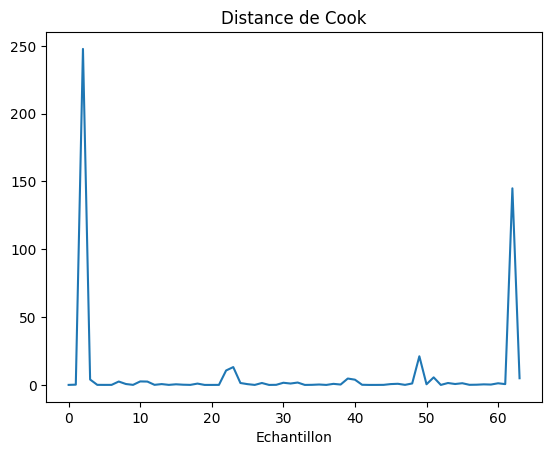

Indices des deux plus grandes valeurs : [ 2 62]
Valeurs correspondantes : [247.71129539 144.93916761]


In [45]:
# Distance de Cook

def cook(x, y, i):

    x = x.values.reshape(-1, 1)

    n = x.shape[0]

    lr = LinearRegression()
    lr.fit(x, y)
    y_pred = lr.predict(x)

    x_del_i = np.delete(x,i).reshape(-1, 1)
    y_del_i = np.delete(y,i)
    
    lr = LinearRegression()
    lr.fit(x_del_i, y_del_i)

    y_pred_i = lr.predict(x)

    s2 = np.sum((y - y_pred)**2) / n-1
    
    return np.sum((y_pred_i - y_pred)**2) / 2*s2

cook_ = [cook(X['sensor_12'], y, i) for i in range(len(X['sensor_12']))]
plt.plot(cook_)
plt.title('Distance de Cook')
plt.xlabel('Echantillon')
plt.show()

cook_arr = np.array(cook_)

# Indices des deux plus grandes valeurs
indices_max = cook_arr.argsort()[-2:][::-1]  # du plus grand au second plus grand

# Valeurs correspondantes
valeurs_max = cook_arr[indices_max]

print("Indices des deux plus grandes valeurs :", indices_max)
print("Valeurs correspondantes :", valeurs_max)

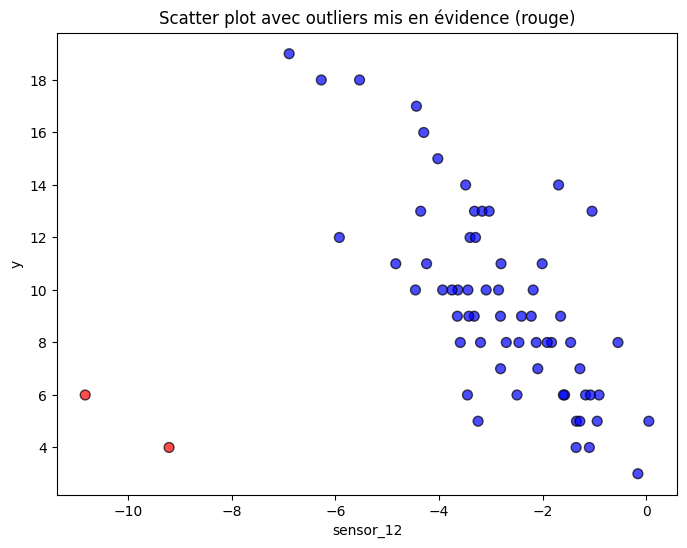

In [80]:
highlight_indices = indices_max

# Créer un tableau de couleurs : rouge pour les points à mettre en évidence, bleu sinon
colors = np.array(['blue'] * len(x))
colors[highlight_indices] = 'red'

plt.figure(figsize=(8,6))
plt.scatter(x, y, c=colors, s=50, edgecolor='k', alpha=0.7)
plt.xlabel("sensor_12")
plt.ylabel("y")
plt.title("Scatter plot avec outliers mis en évidence (rouge)")
plt.show()

On a trouvé les 2 outliers grâce à la distance de cook.

#### QUESTION 2.3.2

**Stratégie 2** : Nous allons ici utiliser toutes les observations pour l'apprentissage du modèle linéaire et sa validation. En supposant que les erreurs de prédiction suivent une loi normale centrée, pourrait-on aussi détecter les outliers à partir d'un test d'hypothèse. Si oui, décrivez la procédure.

(Voir cours sur résidus studentisés)

On peut calculer les résidus studentisés, sous hypothèse de normalité des résidus, ils suivent une loi de student.

Tester l'hypothèse que chaque résidu studentisé est bien généré par cette loi.

On compare en pratique aux bornes [-2, 2]

In [ ]:

n = y.shape[0]

x = X['sensor_12'].values.reshape(-1, 1)

mean_x = np.mean(x)
var_x = np.var(x)

lr = LinearRegression().fit(x, y)
y_pred = lr.predict(x)
residuals = (y - y_pred).values

# Matrice H
H = np.zeros((n,n))
for i in range(n):
    for j in range(n):
        H[i, j] = 1/n + (x[i]-mean_x)*(x[j]-mean_x)/np.sum((x - mean_x)**2)

hii = np.diag(H)

sigma_i = np.sqrt(((n-1)*np.var(residuals) - residuals**2/(1-hii)) / (n-3))

# Résidus studentisés
t_i = residuals / (sigma_i * np.sqrt(1 - hii))

outliers_simple = np.where(np.abs(t_i) > 2)[0]

outliers_simple


/tmp/ipykernel_2081/2464070940.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H[i, j] = 1/n + (x[i]-mean_x)*(x[j]-mean_x)/np.sum((x - mean_x)**2)


array([ 2, 22, 49, 62])

On détecte bien les deux points 2 et 62, et en plus 22 et 49.

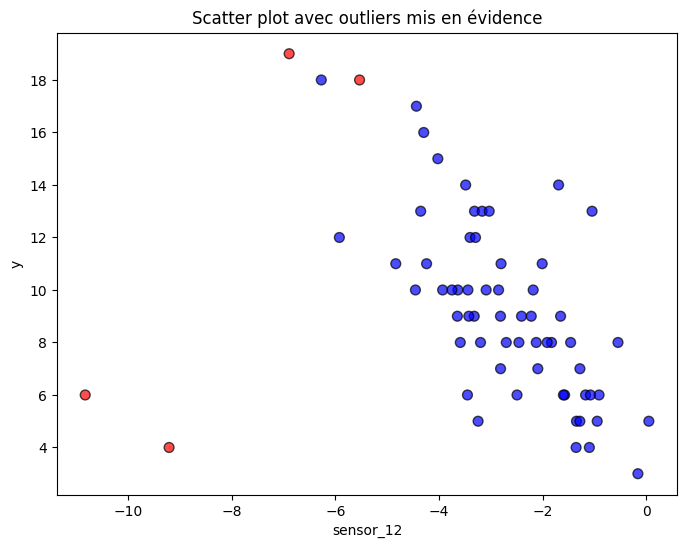

In [ ]:
highlight_indices = outliers_simple

# Créer un tableau de couleurs : rouge pour les points à mettre en évidence, bleu sinon
colors = np.array(['blue'] * len(x))
colors[highlight_indices] = 'red'

plt.figure(figsize=(8,6))
plt.scatter(x, y, c=colors, s=50, edgecolor='k', alpha=0.7)
plt.xlabel("sensor_12")
plt.ylabel("y")
plt.title("Scatter plot avec outliers mis en évidence (rouge)")
plt.show()


### QUESTION 2.4


Nous supprimerons dans cette question les deux observations qui sont aberrantes sur la variable *sensor_12*.

Nous souhaitons maintenant sélectionner automatiquement un nombre réduit, mais supérieur à 1, de capteurs qui nous permettraient de prédire au mieux le niveau de stress. Nous allons pour cela utiliser la régression multiple avec un terme de régularisation.



#### QUESTION 2.4.1

Avant d'effectuer une régression linéaire régularisée, il est vivement conseillé d'effectuer une étape de centrage réduction des données. Pourquoi ?

In [38]:
# voir cours

In [51]:
X_no_outlier = np.delete(X, obj=[2, 62], axis=0)

y_no_outlier = np.delete(y, obj=[2, 62], axis=0)

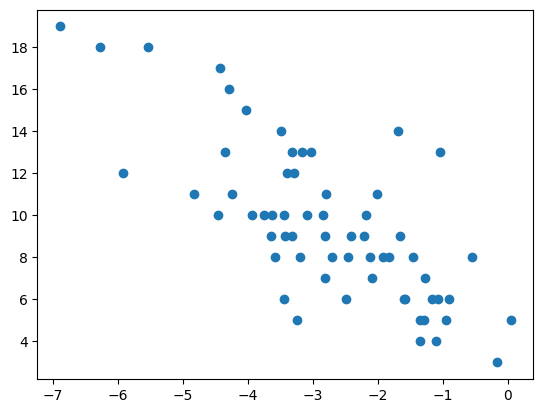

In [52]:
plt.scatter(X_no_outlier[:, 11], y_no_outlier)

#### QUESTION 2.4.2

Décrivez votre démarche de sélection de variables et vos résultats. Est-ce que l'utilisation des données capteurs vous semble fiable ? 

On utilise la régression avec régularisation Lasso. La régularisation avec pénalité sur la norme 1 a pour effet de réduire certains coefficients à zéro, ce qui équivaut à une sélection automatique des variables. Si le alpha est bien choisi, les coefficients non nuls sont ceux qui sont pertinents pour décrire la variable explicative.

On ajuste plusieurs régressions Lasso en modifiant alpha à chaque fois ("grid search", on parcourt une grille d'alphas). On garde le meilleur alpha au sens du coefficient $R^2$.

In [36]:
# Lasso sur tout, devrait sélectionner seulement les variables importantes. Faire une grid search avec validation croisée pour trouver le meilleur alpha.

# Pipeline : centrage réduction + Lasso
lasso_pipeline = make_pipeline(
    StandardScaler(with_mean=True, with_std=True), # centre et réduit les features de X
    Lasso(random_state=42) # régression lasso
)

# Grille de valeurs pour alpha

# param_grid = {
#     'lasso__alpha': [0.001, 0.01, 0.1, 1, 10]
# }

param_grid = {
    'lasso__alpha': [0.1, 0.2, 0.4, 0.6, 0.8]
}

# Définir validation croisée
cv = KFold(n_splits=8, shuffle=True, random_state=42)

# GridSearch
grid_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
)

grid_search.fit(X_no_outlier, y_no_outlier) # Pour chaque alpha, ajuste un modèle Lasso avec validation croisée

# Résultats
print("Meilleur alpha :", grid_search.best_params_['lasso__alpha'])
print("Meilleur score R² :", grid_search.best_score_)

# Tableau récap
results = pd.DataFrame(grid_search.cv_results_)
print(results[['param_lasso__alpha', 'mean_test_score']])

# Récupérer le meilleur modèle trouvé
best_lasso = grid_search.best_estimator_.named_steps['lasso']

# Coefficients
print("Coefficients :", best_lasso.coef_)
print("Intercept :", best_lasso.intercept_)

Meilleur alpha : 0.6
Meilleur score R² : 0.5763216815222361
   param_lasso__alpha  mean_test_score
0                 0.1         0.483600
1                 0.2         0.545730
2                 0.4         0.574696
3                 0.6         0.576322
4                 0.8         0.555275
Coefficients : [ 0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.          0.         -0.         -1.04021367
 -0.          0.          1.87133508 -0.         -0.        ]
Intercept : 9.516129032258064



En examinant les coefficients du modèle Lasso, on remarque que les seuls coefficients non nuls sont ceux correspondant aux capteurs sensor_12 et sensor_15. C'est conforme à ce qu'on a étudié auparavant.

D'après la régression Lasso, il suffit des capteurs sensor_12 et sensor_15 pour expliquer le stress subit par les ailes d'avions.

Toutefois, on remarque que le score $R^2$ est assez faible (0.58). La pertinence du modèle linéaire est donc à discuter.

#### QUESTION 2.4.3

Quelle démarche auriez-vous pour rendre compte des résultats de cette étude sachant que les données contenaient tout de même deux outliers ?